# **Business news and US inflation: which topics matter and why?**
#### Based on the framework of Bybee, Kelly, Manela, & Xiu (2021)

**Authors:** Emma LEGUAY, Carla LUCAS

**Institution:** ENSAE Paris / IP Paris

This project explores the relationship between business news narratives and economic fluctuations. We analyze how latent topics extracted from business news track real-time economic activity.

While grounded in the original study's approach to real activity and asset prices, this notebook extends the analysis to investigate the predictive power of news attention on **U.S. Inflation dynamics (CPI & PCE)**.


### *Import*

In [6]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import lars_path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas_datareader.data as web
import warnings
import os
from src.config import START_DATE, END_DATE, N_VARS_LASSO
from src.utils import *
from src.data_loader import *

warnings.filterwarnings('ignore')
print(f"Environment loaded. Analysis period: {START_DATE} to {END_DATE}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Environment loaded. Analysis period: 1984-01-01 to 2017-06-01


In [7]:
theta, labels_map = load_topics('data')
print(f"Topics loaded: {theta.shape[1]} topics over {len(theta)} months.")

Topics loaded: 180 topics over 402 months.


### **News data and inflation : sparse topic regression**

##### *1. Configuration and data*

In [8]:
NAME_MAPPING = {'CPI': 'CPI Inflation', 'PCEPI': 'PCE Inflation'}

TICKERS = {'CPIAUCSL': 'CPI', 'PCEPI': 'PCEPI'}

fred_raw = web.DataReader(list(TICKERS.keys()), 'fred', start='1980-01-01')
fred_m = fred_raw.resample('MS').mean()
data = pd.DataFrame(index=fred_m.index)
    
data['CPI'] = np.log(fred_m['CPIAUCSL']).diff() * 1200
data['PCEPI'] = np.log(fred_m['PCEPI']).diff() * 1200

data = data.dropna()

common = theta.index.intersection(data.index)
X = theta.loc[common]
Y = data.loc[common]

##### *2. Function*

In [9]:
def run_forecast_analysis(short_name, full_name, y_target, X_features):
    MIN_TRAIN_SIZE = 120
    N_VARS = 5
    
    # STANDARDIZATION 
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    
    X_std = pd.DataFrame(scaler_X.fit_transform(X_features), index=X_features.index, columns=X_features.columns)
    y_std = pd.Series(scaler_y.fit_transform(y_target.values.reshape(-1,1)).flatten(), index=y_target.index)
    
    # A. IN-SAMPLE ANALYSIS
    # Selection of top 5 variables
    top_5_vars = select_exact_k_lars(X_std, y_std, k=N_VARS)
    
    X_ols = sm.add_constant(X_std[top_5_vars])
    model = sm.OLS(y_std, X_ols).fit()
    r2_in = model.rsquared
    
    # B. OUT-OF-SAMPLE ANALYSIS
    trues_oos = []
    preds_oos = []
    hist_means = []
    
    for i in range(MIN_TRAIN_SIZE, len(y_std)):
        y_train = y_std.iloc[:i]
        X_train = X_std.iloc[:i]
        y_test_pt = y_std.iloc[i]
        X_test_row = X_std.iloc[[i]]
        
        # Selection of top 5 variables
        vars_t = select_exact_k_lars(X_train, y_train, k=N_VARS)
        
        # Fit & predict
        reg = LinearRegression().fit(X_train[vars_t], y_train)
        pred = reg.predict(X_test_row[vars_t])[0]
        
        preds_oos.append(pred)
        trues_oos.append(y_test_pt)
        hist_means.append(y_train.mean())

    # R2 OOS
    mse_model = np.mean((np.array(trues_oos) - np.array(preds_oos))**2)
    mse_bench = np.mean((np.array(trues_oos) - np.array(hist_means))**2)
    r2_out = 1 - (mse_model / mse_bench)
    
    # C. TABLES
    res = pd.DataFrame({
        'Coeff': model.params[top_5_vars], 
        'Pval': model.pvalues[top_5_vars]
    })
    res['Topic'] = [labels_map.get(str(v), v) if str(v) in labels_map else labels_map.get(v, v) for v in res.index]
    res = res.sort_values(by='Coeff', key=abs, ascending=False)
    
    print(f"\n{'-'*75}")
    print(f"TABLE : {full_name.upper()}")
    print(f"{'-'*75}")
    print(f"{'Topic':<35} | {'Coeff.':>7} | {'P-val':>8} | {'Sig'}")
    print(f"{'-'*75}")
    
    for _, row in res.iterrows():
        star = get_stars(row['Pval'])
        print(f"{row['Topic']:<35} | {row['Coeff']:>7.2f} | {row['Pval']:>8.4f} | {star}")
        
    print(f"{'-'*75}")
    print(f"In-Sample R2     : {r2_in:.2f}")
    print(f"Out-of-Sample R2 : {r2_out:.2f}")
    print(f"{'-'*75}")
    
    # D. GRAPHS
    vars_final = select_exact_k_lars(X_std, y_std, k=N_VARS)
    reg_final = LinearRegression().fit(X_std[vars_final], y_std)
    preds_in_sample = reg_final.predict(X_std[vars_final])

    dates_oos = y_std.index[MIN_TRAIN_SIZE:] 
    preds_oos_aligned = pd.Series(preds_oos, index=dates_oos)

    plt.figure(figsize=(12, 5))
    plt.plot(y_std.index, y_std, 'k-', lw=1, alpha=0.3, label='Actual data')
    plt.plot(y_std.index, preds_in_sample, 'b--', lw=1, alpha=0.8, label='In-sample fit (explain)')
    plt.plot(dates_oos, preds_oos_aligned, 'r-', lw=1.5, label='Out-of-sample forecast')
    
    plt.axvline(y_std.index[MIN_TRAIN_SIZE], color='gray', linestyle=':', label='OOS start')
    plt.title(f"{full_name}: Topic model performance")
    plt.legend()
    plt.tight_layout()
    
    plt.show()

##### *3. Execution*


---------------------------------------------------------------------------
TABLE : CPI INFLATION
---------------------------------------------------------------------------
Topic                               |  Coeff. |    P-val | Sig
---------------------------------------------------------------------------
Recession                           |   -0.23 |   0.0000 | ***
Germany                             |    0.12 |   0.0147 | **
European sovereign debt             |   -0.09 |   0.1247 | 
Macroeconomic data                  |    0.08 |   0.1615 | 
Aerospace/defense                   |    0.03 |   0.5594 | 
---------------------------------------------------------------------------
In-Sample R2     : 0.15
Out-of-Sample R2 : 0.02
---------------------------------------------------------------------------


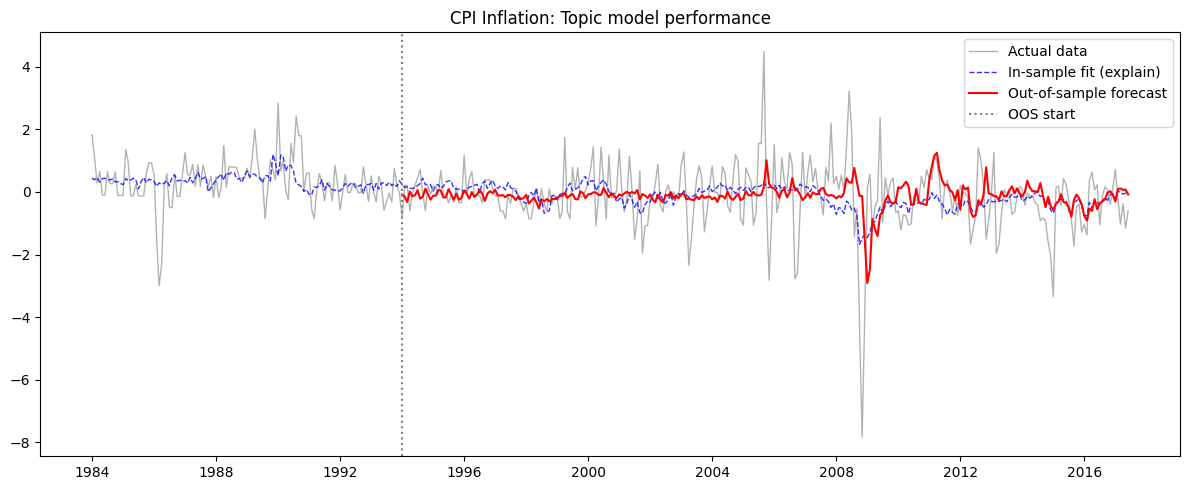


---------------------------------------------------------------------------
TABLE : PCE INFLATION
---------------------------------------------------------------------------
Topic                               |  Coeff. |    P-val | Sig
---------------------------------------------------------------------------
Recession                           |   -0.26 |   0.0000 | ***
Small changes                       |    0.12 |   0.0204 | **
Aerospace/defense                   |    0.08 |   0.1670 | 
European sovereign debt             |   -0.08 |   0.1776 | 
Macroeconomic data                  |    0.07 |   0.2546 | 
---------------------------------------------------------------------------
In-Sample R2     : 0.20
Out-of-Sample R2 : 0.14
---------------------------------------------------------------------------


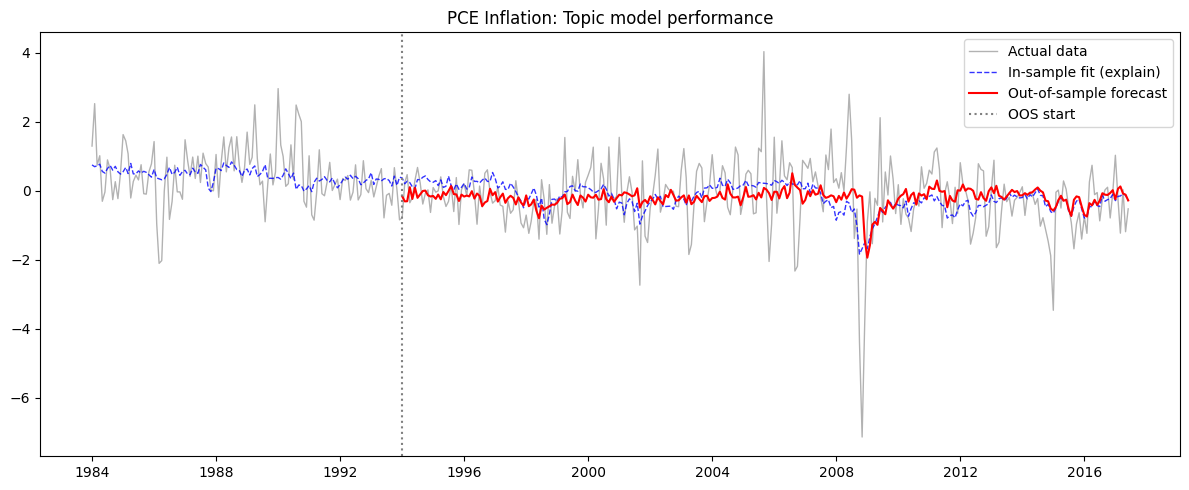

In [10]:
for short_col, full_name in NAME_MAPPING.items():
    if short_col in Y.columns:
        run_forecast_analysis(short_col, full_name, Y[short_col], X)